In [1]:
%load_ext watermark
%watermark -a "Manuel Elias Orellana Lavayen" -d -v -iv

Author: Manuel Elias Orellana Lavayen

Date: 2026-10-05

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 9.17.1

debugpy: 1.8.22



In [2]:
import pandas as pd
from FuncionResumenDataset import resumen_dataset
import matplotlib.pyplot as  plt
from pathlib import Path
ruta_base = Path().cwd().parent
ruta_base

WindowsPath('C:/Users/ManuelOrellana/Desktop/Proyectos Aplicaciones/Aplicacion Prediccion Productos/Creacion de Modelos/Analisis y entrenamiento de modelos/Datasets/Originales')

In [3]:
df = pd.read_csv(filepath_or_buffer= ruta_base/ "transactions.csv", parse_dates=["date"])
df.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [4]:
resumen_dataset(dataframe= df, columnas_excluir=["date", "transactions"])


════════════════════════════════════════════════════════════
═══════════════════ RESUMEN DEL DATASET ════════════════════
════════════════════════════════════════════════════════════
 COLUMNA: STORE_NBR
────────────────────────────────────────────────────────────
  • Número de filas:        83488
  • Tipo de dato:           int64
  • Cantidad datos únicos:  54
  • Valores únicos:         [np.int64(25), np.int64(1), np.int64(2), np.int64(3), np.int64(4)] ... (total 54)
  • Distribución de datos:
      - 26                        :   2.01%
      - 31                        :   2.01%
      - 33                        :   2.01%
      - 34                        :   2.01%
      - 37                        :   2.01%
      - 38                        :   2.01%
      - 39                        :   2.01%
      - 2                         :   2.01%
      - 5                         :   2.01%
      - 16                        :   2.01%
      - 23                        :   2.01%
      - 27     

In [5]:
print("====== Columna 'date' ======")
print("minimo: ", df["date"].min())
print("maximo: ", df["date"].max())

====== Columna 'date' ======
minimo:  2013-01-01 00:00:00
maximo:  2017-08-15 00:00:00


In [6]:
print("====== Valores Nulos ======")
print("date          : ", df["date"].isnull().sum())
print("store_nbr     : ", df["store_nbr"].isnull().sum())
print("transactions  : ", df["transactions"].isnull().sum())

====== Valores Nulos ======
date          :  0
store_nbr     :  0
transactions  :  0


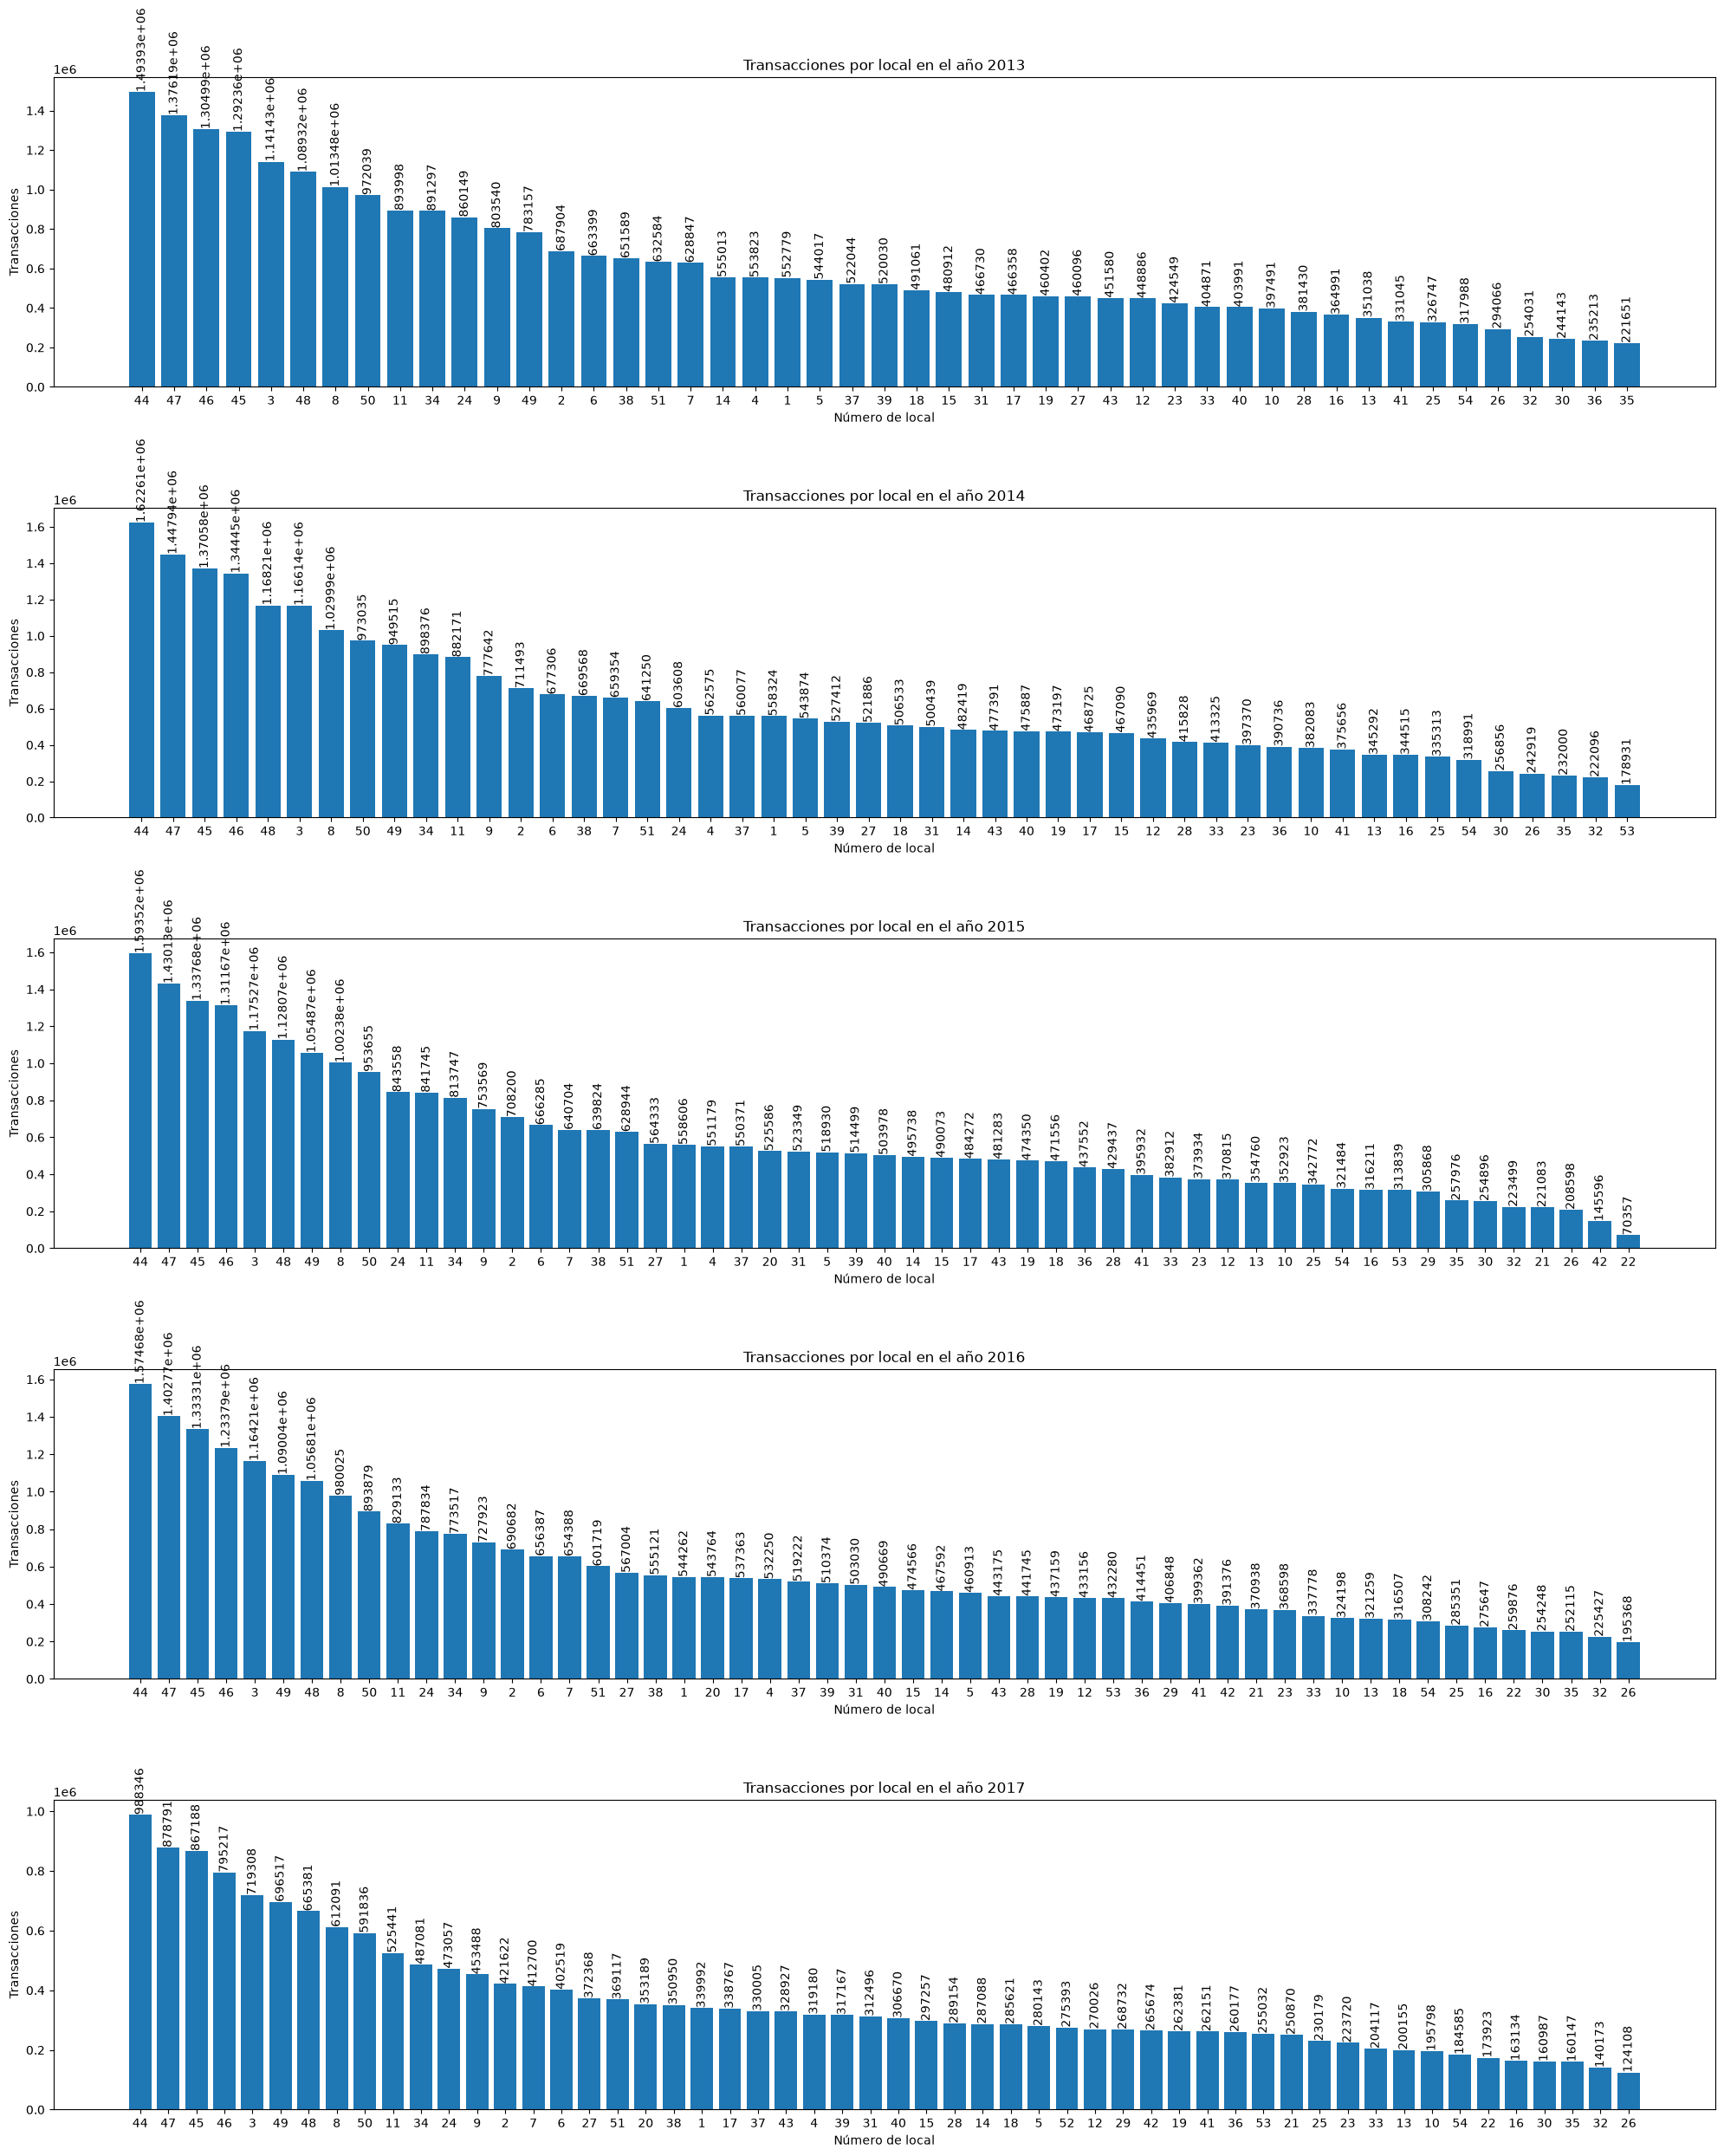

In [7]:
df2 = df.copy()
df2["año"] = df2["date"].dt.year
df2 = df2.drop(columns=["date"])
df2 = df2.groupby(["año", "store_nbr"], as_index= False)["transactions"].sum()

anios = df2["año"].unique()
tiendas = df2["store_nbr"].unique()

fig, axs = plt.subplots(nrows= len(anios) , figsize=(20, 25))
for i in range(len(anios)):
    df_temporal = df2[df2["año"]== anios[i]]
    df_temporal = df_temporal.sort_values(by= "transactions", ascending=False)
    axs[i].set_title(f"Transacciones por local en el año {anios[i]}")
    figura = axs[i].bar(list(map(str, df_temporal["store_nbr"])), df_temporal["transactions"])
    axs[i].bar_label(figura, rotation= 90)
    axs[i].set_xlabel("Número de local")
    axs[i].set_ylabel("Transacciones")

plt.tight_layout()
plt.show()


In [8]:
df[df["date"] == "2016-01-04"]

,date,store_nbr,transactions
52428,2016-01-04,1,10
52429,2016-01-04,5,1485
52430,2016-01-04,23,1119
52431,2016-01-04,24,2491
52432,2016-01-04,25,938
52433,2016-01-04,26,660
52434,2016-01-04,30,599
52435,2016-01-04,31,1510
52436,2016-01-04,32,605
52437,2016-01-04,33,1122
